In [ ]:

import os
import random
import numpy as np
import torch


try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')
$

    SAVE_DIR = '/content/drive/MyDrive/spider_ml_task_1/base_task/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"All outputs will be securely saved to: {SAVE_DIR}\n")
except ImportError:
    print("Not running in Google Colab. Files will be saved locally.")
    SAVE_DIR = './'


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")


Mounting Google Drive...
Mounted at /content/drive
All outputs will be securely saved to: /content/drive/MyDrive/spider_ml_task_1/base_task/

Using device: cuda



In [5]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

VALIDATION_SPLIT = 0.1
BATCH_SIZE = 128
NUM_WORKERS = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(28, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("Downloading and preparing datasets...")
raw_train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True)

train_size = int((1 - VALIDATION_SPLIT) * len(raw_train_dataset))
val_size = len(raw_train_dataset) - train_size
indices = torch.randperm(len(raw_train_dataset)).tolist()
train_indices, val_indices = indices[:train_size], indices[train_size:]

train_dataset = Subset(
    datasets.FashionMNIST(root="./data", train=True, download=False, transform=train_transform),
    train_indices
)
val_dataset = Subset(
    datasets.FashionMNIST(root="./data", train=True, download=False, transform=eval_transform),
    val_indices
)
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=eval_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=device.type == "cuda"
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=device.type == "cuda"
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=device.type == "cuda"
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}\n")

Train size: 54000, Val size: 6000, Test size: 10000



In [9]:
import torch.nn as nn
import torch.optim as optim
import os

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 5
EPOCHS = 20
SAVE_DIR = '/content/drive/MyDrive/spider_ml_task_1/base_task/'
os.makedirs(SAVE_DIR, exist_ok=True)

class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.15),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = FashionCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-6
)

def train_one_epoch():
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        total += labels.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
    return running_loss / total, correct / total * 100

def evaluate(loader):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            total += labels.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
    return running_loss / total, correct / total * 100

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_val_loss = float("inf")
early_stop_counter = 0

best_model_path = os.path.join(SAVE_DIR, "best_fashion_model.pth")

print("Beginning Training...\n")
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc = evaluate(val_loader)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    print(f"Epoch [{epoch}/{EPOCHS}] Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    if early_stop_counter >= PATIENCE:
        print(f"\nEarly stopping triggered after {epoch} epochs.")
        break

if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"\nLoaded best model from Drive with val acc {best_val_acc:.2f}%\n")

Beginning Training...

Epoch [1/20] Train Loss: 0.8859, Train Acc: 67.76% | Val Loss: 0.5045, Val Acc: 79.97%
Epoch [2/20] Train Loss: 0.6011, Train Acc: 77.22% | Val Loss: 0.4644, Val Acc: 81.65%
Epoch [3/20] Train Loss: 0.5291, Train Acc: 80.34% | Val Loss: 0.3814, Val Acc: 85.53%
Epoch [4/20] Train Loss: 0.4849, Train Acc: 82.04% | Val Loss: 0.3386, Val Acc: 87.77%
Epoch [5/20] Train Loss: 0.4483, Train Acc: 83.63% | Val Loss: 0.3529, Val Acc: 87.00%
Epoch [6/20] Train Loss: 0.4246, Train Acc: 84.47% | Val Loss: 0.2916, Val Acc: 89.52%
Epoch [7/20] Train Loss: 0.4066, Train Acc: 85.10% | Val Loss: 0.3126, Val Acc: 88.37%
Epoch [8/20] Train Loss: 0.3897, Train Acc: 85.89% | Val Loss: 0.2797, Val Acc: 89.80%
Epoch [9/20] Train Loss: 0.3707, Train Acc: 86.66% | Val Loss: 0.2581, Val Acc: 90.63%
Epoch [10/20] Train Loss: 0.3657, Train Acc: 86.91% | Val Loss: 0.2589, Val Acc: 90.53%
Epoch [11/20] Train Loss: 0.3512, Train Acc: 87.26% | Val Loss: 0.2641, Val Acc: 90.37%
Epoch [12/20] Trai

Performance plots saved to Drive: /content/drive/MyDrive/spider_ml_task_1/base_task/accuracy_loss_plots.png


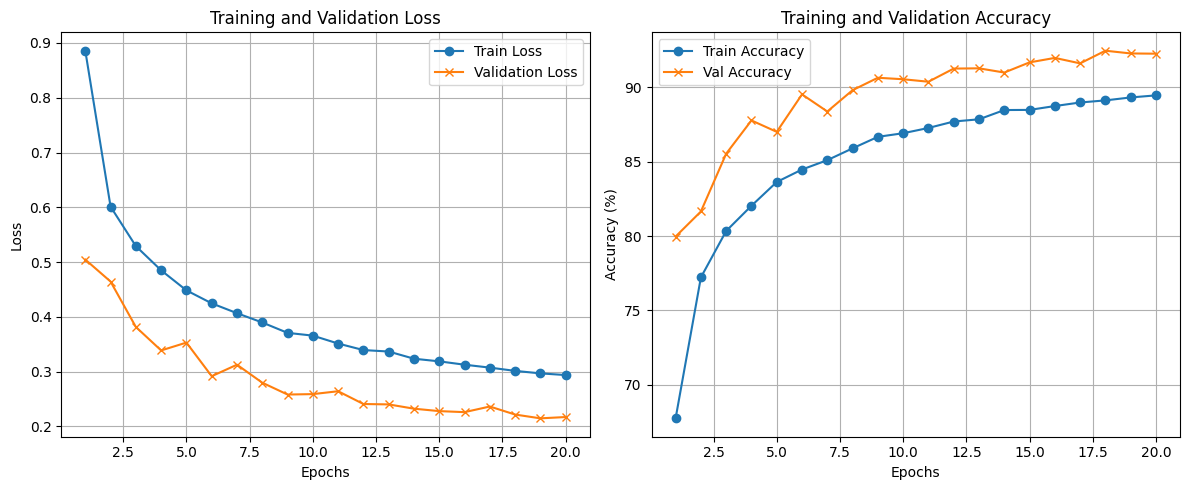

Model weights safely saved to Drive: '/content/drive/MyDrive/spider_ml_task_1/base_task/fashion_model_weights.pkl'.

Generating predictions for the test dataset...
Submission file generated and saved to Drive: '/content/drive/MyDrive/spider_ml_task_1/base_task/submission.csv'


In [10]:

import pickle
import pandas as pd
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss", marker="x")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy", marker="o")
plt.plot(epochs_range, history["val_acc"], label="Val Accuracy", marker="x")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()

plot_path = os.path.join(SAVE_DIR, "accuracy_loss_plots.png")
plt.savefig(plot_path)
print(f"Performance plots saved to Drive: {plot_path}")
plt.show()

weights_filename = os.path.join(SAVE_DIR, "fashion_model_weights.pkl")
with open(weights_filename, "wb") as f:
    pickle.dump(model.state_dict(), f)
print(f"Model weights safely saved to Drive: '{weights_filename}'.")

model.eval()
test_predictions = []
print("\nGenerating predictions for the test dataset...")
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_predictions.extend(predicted.cpu().numpy())

submission_df = pd.DataFrame({
    "Index": np.arange(len(test_predictions)),
    "Label": test_predictions,
})

submission_filename = os.path.join(SAVE_DIR, "submission.csv")
submission_df.to_csv(submission_filename, index=False)
print(f"Submission file generated and saved to Drive: '{submission_filename}'")